**Enunciado:**\
El objetivo de este tutorial es que sirva de repaso de algunos de los conceptos básicos que
tienen que conocerse de estas librerías.  

Se pide desarrollar un código (archivo main.ipynb) que realice operaciones similares
sobre el conjunto de datos Breast Cancer Wisconsin, el cual está incluido en Sklearn.  

Finalmente, se tiene que redactar un informe con los resultados obtenidos y las
conclusiones que se pueden extraer.
  El informe tiene que estar escrito en Latex usando la
plantilla LNCS.

In [ ]:
# ------------------------------------------------------------------------------
# Importaciones
# ------------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# ------------------------------------------------------------------------------
# Funciones auxiliares 
# ------------------------------------------------------------------------------
def space():
  print("\n")
def title(str):
  print("\n# ----------------------------------------------------------------------------------------")
  print(f"# {str}")
  print("# ----------------------------------------------------------------------------------------\n")


Importamos las liberías que vamos a emplear para el desarrollo de la práctica.

In [ ]:
# ------------------------------------------------------------------------------
# Cargar datos
# ------------------------------------------------------------------------------
breast_cancer = load_breast_cancer()
df = pd.DataFrame(data = breast_cancer.data, columns = breast_cancer.feature_names)
df['target'] = breast_cancer.target
print(df['target'])

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


Usaremos el conjunto de datos sobre el diagnóstico del cáncer de mama de Wisconsin, la cual es accesible en este enlace: [Breast Cancer Wisconsin ICS](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic).

In [ ]:
# ------------------------------------------------------------------------------
# NumPy: Estadísticas básicas
# ------------------------------------------------------------------------------
# Crear un array manual con np.array
radius_breast = np.array(df['mean radius'])
# Calcular media, mediana, desviación típica de una columna del dataset
title("Estadísticas básicas sobre las distancias desde el centro a los puntos perimetrales:")
print("Media:", np.mean(radius_breast))
print("Desviación típica:", np.std(radius_breast))
print("Mediana:", np.median(radius_breast))


# ----------------------------------------------------------------------------------------
# Estadísticas básicas sobre las distancias desde el centro a los puntos perimetrales:
# ----------------------------------------------------------------------------------------

Media: 14.127291739894552
Desviación típica: 3.520950760711062
Mediana: 13.37


Calculamos las estadísticas básicas sobre la media de los radios.

In [ ]:
# ------------------------------------------------------------------------------
# Pandas: Exploración
# ------------------------------------------------------------------------------
# Devolver las primeras n filas (por defecto, n=5)
title("Head:")
print(df.head())
# Generar estadísticas
title("Estadísticas generales:")
print(df.describe())
# Filtrar por clase
title("Filtrado por clase 1 (diagnóstico positivo):")
print(df[df["target"] == 1])
# Agrupar por clase y hacer media
title("Agrupar por diagnóstico y hacer media")
print("Media por clase:")
print(df.groupby("target").mean())


# ----------------------------------------------------------------------------------------
# Head:
# ----------------------------------------------------------------------------------------

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.

Manipulación del dataframe con diferentes funciones de Pandas.


# ----------------------------------------------------------------------------------------
# Histograma sobre la textura media (desviación estándar de los valores de escala de grises)
# ----------------------------------------------------------------------------------------



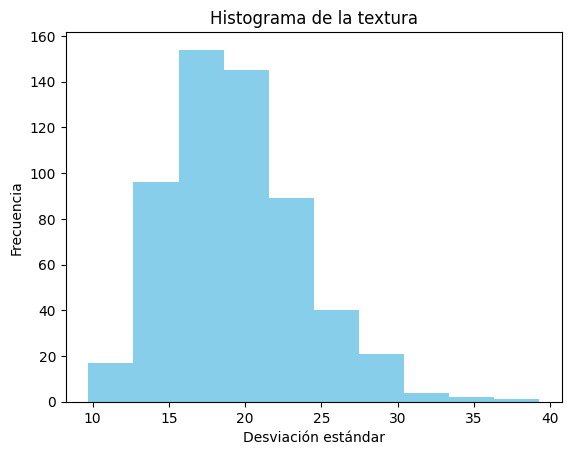

In [ ]:
# ------------------------------------------------------------------------------
# --- Matplotlib: Visualizaciones ---
# ------------------------------------------------------------------------------
title("Histograma sobre la textura media (desviación estándar de los valores de escala de grises)")
plt.hist(df['mean texture'], bins=10, color='skyblue')
plt.title('Histograma de la textura')
plt.xlabel('Desviación estándar')
plt.ylabel('Frecuencia')
plt.show()

Histograma sobre la textura media.

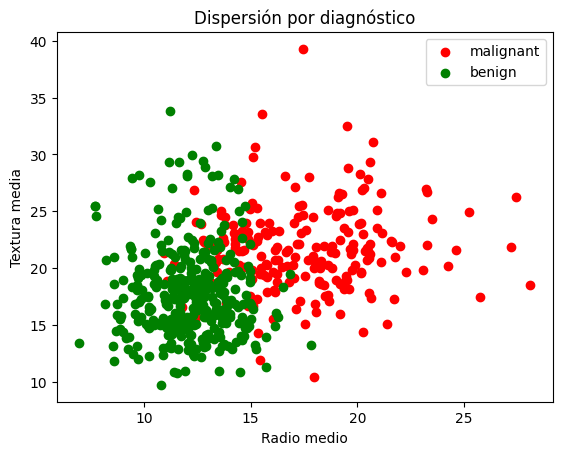

In [ ]:
# Scatter plot
colors = ['red', "green"]
for i in range(2):
    plt.scatter(df[df['target'] == i]['mean radius'],
                df[df['target'] == i]['mean texture'],
                label=breast_cancer.target_names[i], color=colors[i])
plt.xlabel('Radio medio')
plt.ylabel('Textura media')
plt.title('Dispersión por diagnóstico')
plt.legend()
plt.show()

Diagrama de dispersión sobre el diagnóstico del tumor.

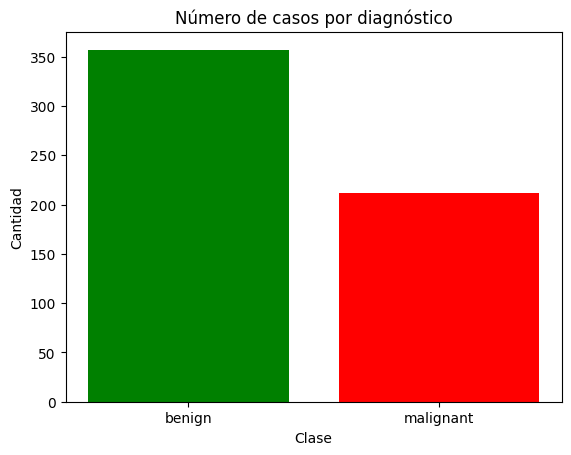

In [ ]:
# Gráfico de barras
counts = df['target'].value_counts()
labels = [breast_cancer.target_names[i] for i in counts.index]

plt.bar(labels, counts, color=['green', 'red'])
plt.title('Número de casos por diagnóstico')
plt.ylabel('Cantidad')
plt.xlabel('Clase')
plt.show()

Diagrama de barras con el número de casos por diagnóstico.

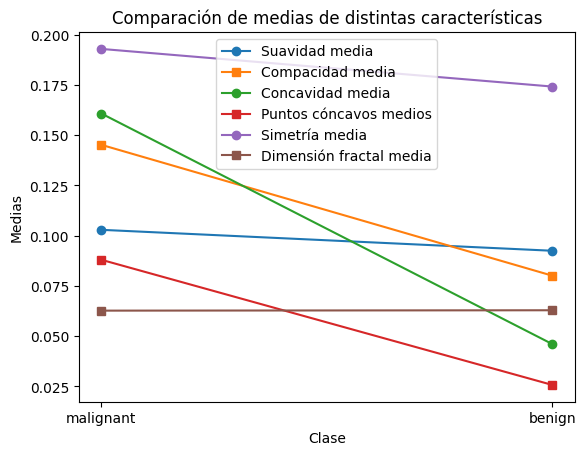

In [ ]:
# Gráfico de líneas
grouped_means = df.groupby('target')[['mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension']].mean()
labels = [breast_cancer.target_names[i] for i in grouped_means.index]

plt.plot(labels, grouped_means['mean smoothness'], label='Suavidad media', marker='o')
plt.plot(labels, grouped_means['mean compactness'], label='Compacidad media', marker='s')
plt.plot(labels, grouped_means['mean concavity'], label='Concavidad media', marker='o')
plt.plot(labels, grouped_means['mean concave points'], label='Puntos cóncavos medios', marker='s')
plt.plot(labels, grouped_means['mean symmetry'], label='Simetría media', marker='o')
plt.plot(labels, grouped_means['mean fractal dimension'], label='Dimensión fractal media', marker='s')


plt.title('Comparación de medias de distintas características')
plt.ylabel('Medias')
plt.xlabel('Clase')
plt.legend()
plt.show()

Diagrama de líneas comparando las medias de ciertas características.

/tmp/ipython-input-2574247311.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=breast_cancer.target_names)


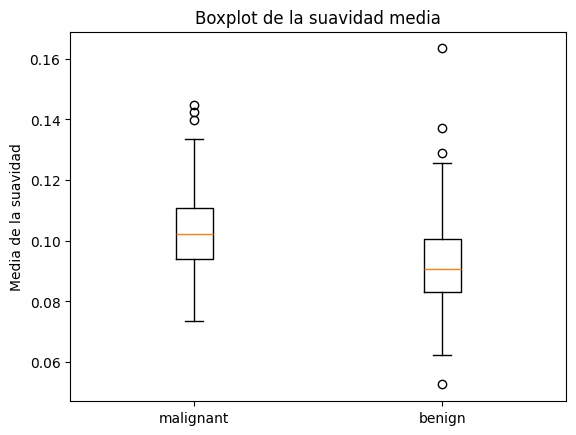

In [ ]:
# Boxplot
data = [df[df['target'] == i]['mean smoothness'] for i in range(2)]
plt.boxplot(data, labels=breast_cancer.target_names)
plt.title('Boxplot de la suavidad media')
plt.ylabel('Media de la suavidad')
plt.show()

Diagrama de cajas sobre la suavidad media.


Precisión del modelo: 0.9473684210526315

Matriz de confusión:
[[40  3]
 [ 3 68]]


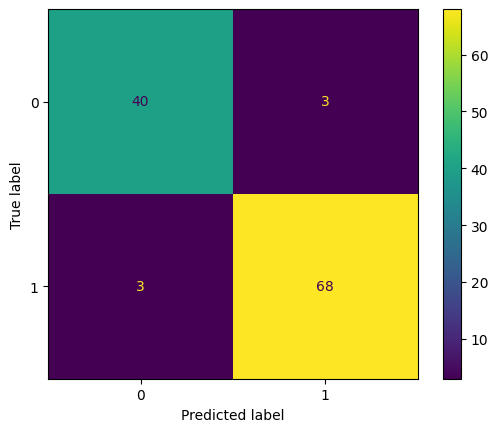

In [ ]:
# --- Scikit-learn: Modelo simple ---
X = df.drop("target", axis=1)
y = df["target"]
# Dividir conjunto de datos en entrenamiento y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Usar un modelo de aprendizaje supervisado
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
# Evaluar el rendimiento del modelo
y_pred = model.predict(X_test)
print("\nPrecisión del modelo:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
print(cm)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()



Matriz de confusión con los verdaderos positivos, verdaderos negativos, falsos
positivos y falsos negativos. Sumado de la precisión del modelo.